# 02. Concepts as masks

To say "this unit detects circles" we need to know where the circles are. Network Dissection turns every concept $c$ into a mask $L_c(x)$: the set of pixels of image $x$ that show $c$. Broden (notebook 00) provides these masks for 1 197 concepts.

Here a tiny Broden is generated from scratch, so every mask is exact and the whole dataset fits in memory.

Comparison: pixel labels vs image labels.

Paper: Sec. 2.1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

plt.rcParams.update({"figure.dpi": 90, "axes.titlesize": 9})

## A tiny Broden

Each image: one colored shape on a textured background.

| category | concepts | label type |
|---|---|---|
| object | circle, square | pixel |
| color | red, green, blue | pixel (the shape pixels) |
| texture | stripes, dots | image |

In [2]:
SIZE = 64
CONCEPTS = ["circle", "square", "red", "green", "blue", "stripes", "dots"]
CATEGORY = {"circle": "object", "square": "object", "red": "color", "green": "color",
            "blue": "color", "stripes": "texture", "dots": "texture"}
RGB = {"red": (0.9, 0.15, 0.15), "green": (0.15, 0.8, 0.2), "blue": (0.2, 0.3, 0.95)}
yy, xx = np.mgrid[:SIZE, :SIZE]


def make_scene(rng):
    """Returns image (3, H, W), concept masks (C, H, W) and the shape class (0 circle, 1 square)."""
    texture = rng.choice(["stripes", "dots"])
    if texture == "stripes":
        period, phase = rng.uniform(5, 9), rng.uniform(0, 6)
        bg = 0.45 + 0.2 * np.sign(np.sin(2 * np.pi * (yy + phase) / period))
    else:
        step = rng.integers(7, 11)
        bg = 0.45 + 0.25 * (((yy % step) < 2) & ((xx % step) < 2))
    image = np.repeat(bg[None], 3, 0)

    shape, color = rng.choice(["circle", "square"]), rng.choice(list(RGB))
    r = rng.integers(7, 13)
    cy, cx = rng.integers(r, SIZE - r, 2)
    if shape == "circle":
        mask = (yy - cy) ** 2 + (xx - cx) ** 2 <= r ** 2
    else:
        mask = (abs(yy - cy) <= r * 0.85) & (abs(xx - cx) <= r * 0.85)
    shade = 1 - 0.25 * np.hypot(yy - cy, xx - cx) / r          # lighter in the middle
    image[:, mask] = np.array(RGB[color])[:, None] * shade[mask]
    image = image + rng.normal(0, 0.03, image.shape)

    masks = np.zeros((len(CONCEPTS), SIZE, SIZE), bool)
    masks[CONCEPTS.index(shape)] = mask
    masks[CONCEPTS.index(color)] = mask
    masks[CONCEPTS.index(texture)] = True
    return image.clip(0, 1).astype(np.float32), masks, int(shape == "square")


def make_dataset(n, seed):
    r = np.random.default_rng(seed)
    images, masks, ys = zip(*(make_scene(r) for _ in range(n)))
    return torch.tensor(np.stack(images)), torch.tensor(np.stack(masks)), torch.tensor(ys)


images, masks, shape = make_dataset(200, seed=0)
print("images", tuple(images.shape), " masks", tuple(masks.shape), " (N, concepts, H, W)")

images (200, 3, 64, 64)  masks (200, 7, 64, 64)  (N, concepts, H, W)


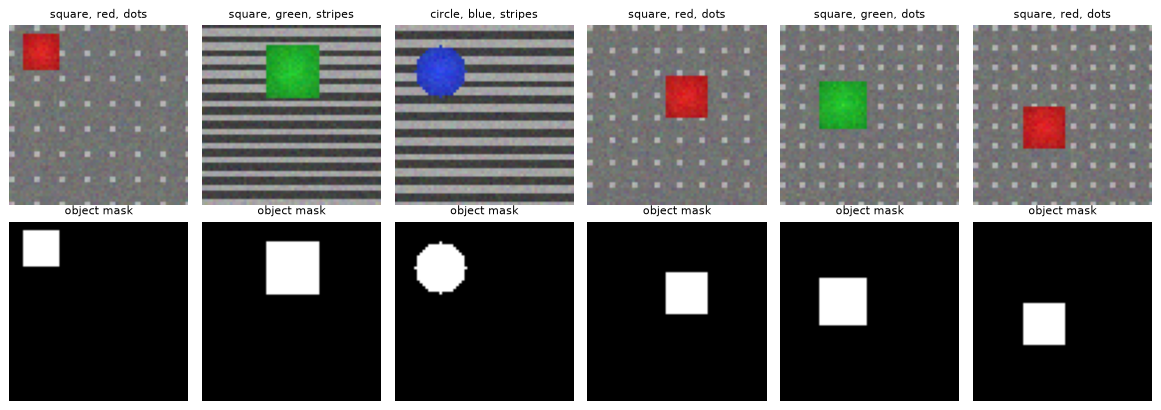

In [3]:
fig, axes = plt.subplots(2, 6, figsize=(13, 4.6))
for col in range(6):
    present = [c for i, c in enumerate(CONCEPTS) if masks[col, i].any()]
    axes[0, col].imshow(images[col].permute(1, 2, 0))
    axes[0, col].set_title(", ".join(present))
    axes[1, col].imshow(masks[col, CONCEPTS.index("circle")] | masks[col, CONCEPTS.index("square")], cmap="gray")
    axes[1, col].set_title("object mask")
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Pixel labels vs image labels

All masks of one image. Object and color masks follow the shape. The texture mask covers the whole image: the label only says "this image has stripes", not where.

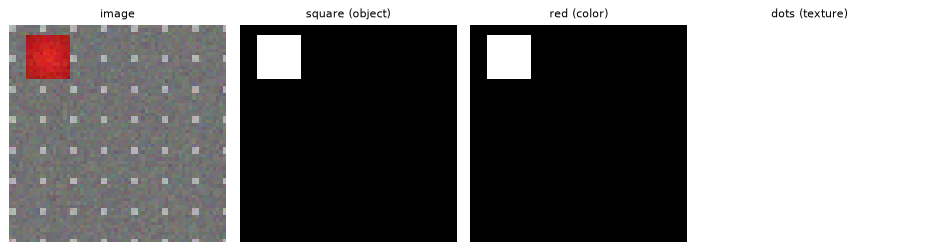

In [4]:
i = 0
present = [c for k, c in enumerate(CONCEPTS) if masks[i, k].any()]
fig, axes = plt.subplots(1, 1 + len(present), figsize=(2.6 * (1 + len(present)), 2.8))
axes[0].imshow(images[i].permute(1, 2, 0))
axes[0].set_title("image")
for ax, c in zip(axes[1:], present):
    ax.imshow(masks[i, CONCEPTS.index(c)], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"{c} ({CATEGORY[c]})")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

The consequence shows up in how much of the image each concept covers. An image label always covers 100 %. A unit can only overlap well with it if it fires on the whole image.

In [5]:
cover = masks.float().mean((2, 3))
for k, c in enumerate(CONCEPTS):
    on = cover[:, k] > 0
    print(f"{c:8s} {CATEGORY[c]:8s} in {int(on.sum()):3d} images, covers {float(cover[on, k].mean()):5.1%} of them")

circle   object   in 105 images, covers  7.2% of them
square   object   in  95 images, covers  6.6% of them
red      color    in  72 images, covers  7.1% of them
green    color    in  55 images, covers  6.7% of them
blue     color    in  73 images, covers  6.8% of them
stripes  texture  in 103 images, covers 100.0% of them
dots     texture  in  97 images, covers 100.0% of them


Objects and colors cover about 6 to 8 % of an image, textures 100 %. Keep these numbers in mind: they decide which threshold makes sense in notebook 03 and which IoU scores are reachable later.

## A unit next to a mask

A preview of the whole method. A hand made "red" unit: red channel minus the mean of the others, then ReLU. Its map against the red mask on a few images, all maps on the same color scale.

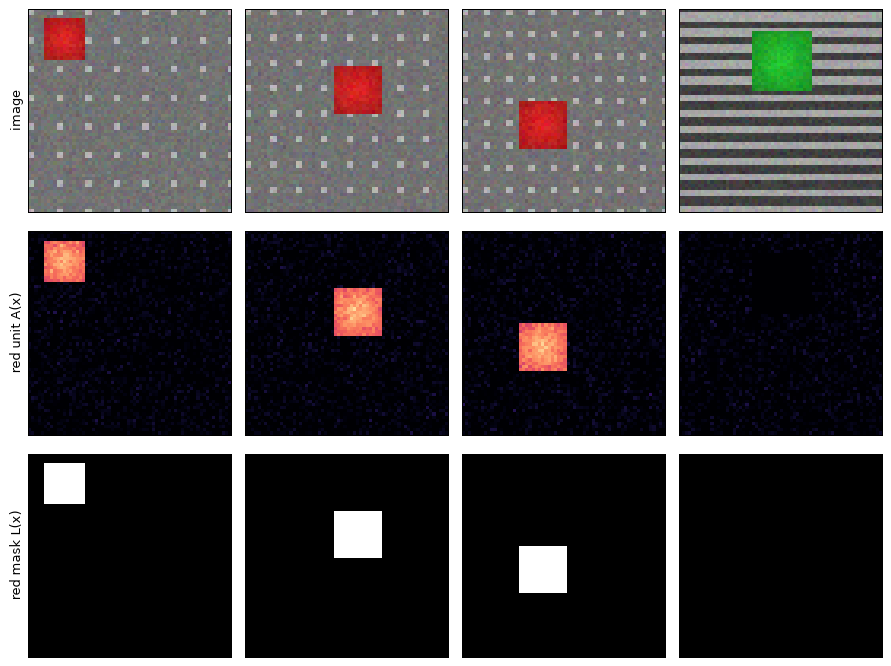

In [6]:
red_unit = torch.relu(images[:, 0] - images[:, 1:].mean(1))
red = masks[:, CONCEPTS.index("red")]
picks = [j for j in range(len(images)) if red[j].any()][:3] + [j for j in range(len(images)) if not red[j].any()][:1]
fig, axes = plt.subplots(3, 4, figsize=(10, 7.6))
for col, j in enumerate(picks):
    axes[0, col].imshow(images[j].permute(1, 2, 0))
    axes[1, col].imshow(red_unit[j], cmap="magma", vmin=0, vmax=float(red_unit.max()))
    axes[2, col].imshow(red[j], cmap="gray", vmin=0, vmax=1)
for row, name in enumerate(["image", "red unit A(x)", "red mask L(x)"]):
    axes[row, 0].set_ylabel(name)
for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

The map and the mask look alike when the shape is red, and the map stays dark otherwise. Notebooks 03 and 04 turn the map into a mask at the right resolution, the IoU score of the paper then turns "look alike" into a number.

Takeaways

* a concept is a set of pixels, one mask per image
* objects and colors are pixel labels, textures (and scenes in Broden) are whole image labels
* how much of the image a concept covers will matter for thresholds and scores